In [30]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

In [28]:
df = pd.read_csv("/content/sleep_apnea_synthetic_data.csv")

In [17]:
print("DataFrame columns:", df.columns.tolist())

DataFrame columns: ['subject_id', 'night_id', 'epoch_index', 'age', 'bmi', 'acc_mean', 'acc_std', 'hr_mean', 'hr_std', 'spo2_mean', 'spo2_min', 'is_apnea_event', 'severity_label']


In [18]:
FEATURE_COLS = [
    "accel_mean", "accel_std", "motion_count", "zero_crossing_rate",
    "hr_mean", "hr_std", "hr_delta", "hr_trend",
    "spo2_mean", "spo2_min", "desaturation_depth", "desaturation_flag", "recovery_time",
    "motion_spo2_lag", "hr_spo2_correlation"
]
LABEL_COL = "severity_label" # Changed from 'severity_class' to 'severity_label'
GROUP_COL = "subject_id"

In [19]:
# Drop rows where 'subject_id' or 'severity_label' is NaN, as these cannot be used for grouping or labeling.
df_cleaned = df.dropna(subset=[GROUP_COL, LABEL_COL]).copy()

# Filter FEATURE_COLS to include only columns present in the cleaned DataFrame
existing_features = [col for col in FEATURE_COLS if col in df_cleaned.columns]

scaler = StandardScaler()
# Fit and transform on the cleaned DataFrame for feature columns
df_cleaned[existing_features] = scaler.fit_transform(df_cleaned[existing_features])

# Update FEATURE_COLS to reflect only the existing features
FEATURE_COLS = existing_features


label_encoder = LabelEncoder()
# Use df_cleaned for grouping and label extraction
subject_labels = df_cleaned.groupby(GROUP_COL)[LABEL_COL].first()
subject_labels_encoded = label_encoder.fit_transform(subject_labels)
num_classes = len(label_encoder.classes_)


sequences = []
labels = []


In [20]:
for subject_id, group in df_cleaned.groupby(GROUP_COL):
    group = group.sort_values("epoch_index")
    seq = group[FEATURE_COLS].values # Use the updated FEATURE_COLS
    sequences.append(seq)
    labels.append(label_encoder.transform([group[LABEL_COL].iloc[0]])[0])

MAX_SEQ_LEN = 200
X = pad_sequences(sequences, maxlen=MAX_SEQ_LEN, dtype="float32", padding="post", truncating="post")
y = to_categorical(labels, num_classes=num_classes)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=labels
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.176, random_state=42,  # ~15% of total
    stratify=np.argmax(y_train, axis=1)
)


In [21]:
model = Sequential([
    Masking(mask_value=0.0, input_shape=(MAX_SEQ_LEN, len(FEATURE_COLS))), # Use the updated FEATURE_COLS
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_2 (Masking)             │ (None, 200, 4)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 200, 64)        │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,268 (122.14 KB)

 Trainable params: 31,268 (122.14 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 582ms/step - accuracy: 0.4052 - loss: 1.3637 - val_accuracy: 0.5152 - val_loss: 1.2942
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step - accuracy: 0.4837 - loss: 1.2812 - val_accuracy: 0.5455 - val_loss: 1.1890
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step - accuracy: 0.4706 - loss: 1.2056 - val_accuracy: 0.5455 - val_loss: 1.0755
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - accuracy: 0.4837 - loss: 1.1478 - val_accuracy: 0.5455 - val_loss: 0.9985
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step - accuracy: 0.4706 - loss: 1.0864 - val_accuracy: 0.4848 - val_loss: 1.0016
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step - accuracy: 0.4837 - loss: 1.0942 - val_accuracy: 0.5152 - val_loss: 0.9702
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 222ms/step - accuracy: 0.4967 - loss: 1.0426 - val_accuracy: 0.4848 - val_loss: 0.9320
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step - accuracy: 0.5163 - loss: 1.0027 - val_accuracy: 0.5455 - v

In [24]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))
print(confusion_matrix(y_true, y_pred))


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6970 - loss: 0.8798
Test Accuracy: 0.6970
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
              precision    recall  f1-score   support

        mild       0.86      0.60      0.71        10
    moderate       0.43      0.43      0.43         7
        none       0.82      1.00      0.90         9
      severe       0.62      0.71      0.67         7

    accuracy                           0.70        33
   macro avg       0.68      0.69      0.68        33
weighted avg       0.71      0.70      0.69        33

[[6 2 1 1]
 [1 3 1 2]
 [0 0 9 0]
 [0 2 0 5]]


In [25]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
)
import matplotlib.pyplot as plt


In [26]:
# ---- Get predicted probabilities (needed for ROC AUC) ----
y_pred_proba = model.predict(X_test)  # shape (n_samples, num_classes)

# ---- Overall accuracy ----
accuracy = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {accuracy:.4f}")

# ---- F1 Score (macro handles class imbalance fairly, weighted accounts for support) ----
f1_macro = f1_score(y_true, y_pred, average="macro")
f1_weighted = f1_score(y_true, y_pred, average="weighted")
print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")

# ---- Precision / Recall (macro) ----
precision_macro = precision_score(y_true, y_pred, average="macro")
recall_macro = recall_score(y_true, y_pred, average="macro")
print(f"Precision (macro): {precision_macro:.4f}")
print(f"Recall (macro): {recall_macro:.4f}")

# ---- ROC AUC (multiclass, one-vs-rest) ----
try:
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class="ovr", average="macro")
    print(f"ROC AUC (macro, OVR): {roc_auc:.4f}")
except ValueError as e:
    print(f"ROC AUC could not be computed: {e}")

# ---- Per-class False Positives / False Negatives (from confusion matrix) ----
cm = confusion_matrix(y_true, y_pred)
n_classes = cm.shape[0]

print("\nPer-class False Positives / False Negatives / True Positives / True Negatives:")
for i, class_name in enumerate(label_encoder.classes_):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP          # actual class i, predicted something else
    FP = cm[:, i].sum() - TP          # predicted class i, actually something else
    TN = cm.sum() - TP - FN - FP
    print(f"Class '{class_name}': TP={TP}, FP={FP}, FN={FN}, TN={TN}")

# ---- Overfitting / Underfitting diagnosis ----
train_acc_final = history.history["accuracy"][-1]
val_acc_final = history.history["val_accuracy"][-1]
train_loss_final = history.history["loss"][-1]
val_loss_final = history.history["val_loss"][-1]

print("\n--- Overfit / Underfit Diagnosis ---")
print(f"Final Train Accuracy: {train_acc_final:.4f} | Final Val Accuracy: {val_acc_final:.4f}")
print(f"Final Train Loss:     {train_loss_final:.4f} | Final Val Loss:     {val_loss_final:.4f}")

acc_gap = train_acc_final - val_acc_final
loss_gap = val_loss_final - train_loss_final

if train_acc_final < 0.6 and val_acc_final < 0.6:
    diagnosis = "Underfitting: both train and validation accuracy are low. Consider a bigger/more expressive model, more epochs, or better features."
elif acc_gap > 0.15 or loss_gap > 0.3:
    diagnosis = "Overfitting: train accuracy/loss is much better than validation. Consider more dropout, regularization, more data, or early stopping (already partially handled)."
else:
    diagnosis = "Good fit: train and validation performance are reasonably close."

print(diagnosis)



2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Overall Accuracy: 0.6970
F1 Score (macro): 0.6753
F1 Score (weighted): 0.6917
Precision (macro): 0.6822
Recall (macro): 0.6857
ROC AUC (macro, OVR): 0.8293

Per-class False Positives / False Negatives / True Positives / True Negatives:
Class 'mild': TP=6, FP=1, FN=4, TN=22
Class 'moderate': TP=3, FP=4, FN=4, TN=22
Class 'none': TP=9, FP=2, FN=0, TN=22
Class 'severe': TP=5, FP=3, FN=2, TN=23

--- Overfit / Underfit Diagnosis ---
Final Train Accuracy: 0.7190 | Final Val Accuracy: 0.7879
Final Train Loss:     0.6965 | Final Val Loss:     0.6436
Good fit: train and validation performance are reasonably close.


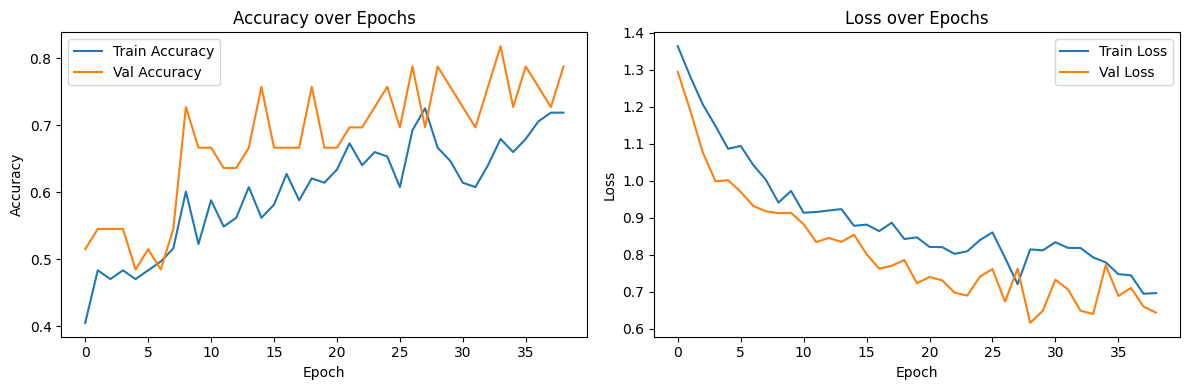

In [27]:
# ---- Plot learning curves for visual confirmation ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()